In [ ]:
# Email Spam Detection using Support Vector Machines
## Data Science & Machine Learning Portfolio — SETU

---

| | |
|---|---|
| **Student** | Emmanuel Abolade |
| **Student Number** | C00288657 |
| **Institution** | South East Technological University, Carlow |
| **Module** | Data Science & Machine Learning 2 |
| **Lecturer** | Greg Doyle |
| **Date** | March 2026 |

---

## Project Overview

**Problem:** Billions of spam and phishing messages flood inboxes daily. Can a machine learn to automatically distinguish spam from legitimate messages?

**Approach:** This project applies a Support Vector Machine (SVM) to the SMS Spam Collection dataset — a real cybersecurity problem requiring accurate, automated text classification.

**Why SVM?** As stated in the course notes: *'SVMs are currently among the best performers for a number of classification tasks ranging from text to genomic data.'* High-dimensional TF-IDF text representations are naturally suited to the linear SVM's maximum margin decision boundary.

## Notebook Structure

| Section | Content |
|---|---|
| 1. Theory | Hyperplanes, margins, kernels, soft margin |
| 2. Dataset | SMS Spam Collection — EDA and preprocessing |
| 3. From-Scratch SVM | Linear SVM built using only NumPy |
| 4. Scikit-learn SVM | TF-IDF pipeline with GridSearchCV |
| 5. Evaluation | Confusion matrix, ROC, feature importance |
| 6. Work Log | Decisions, adjustments, and analysis |
| 7. References | All sources |


---
## Section 1 — Theory: Support Vector Machines

### 1.1 What is an SVM?

A Support Vector Machine is a **supervised learning** algorithm for binary classification. It finds the optimal decision boundary — a **hyperplane** — that maximally separates two classes.

Decision function: **f(x) = sign(w^T x + b)**

Where **w** is the weight vector and **b** is the bias.

### 1.2 The Margin and Support Vectors

SVM maximises the **margin** — the width of the gap between the two class boundaries. The margin equals 2/||w||, so maximising it means minimising ||w||.

**Support vectors** are the training examples closest to the hyperplane. As stated in the lectures: *'The decision function is fully specified by a subset of training samples, the support vectors.'* All other training points are irrelevant to the boundary.

### 1.3 Hard Margin vs Soft Margin (C-SVM)

**Hard margin** assumes perfectly separable data. **Soft margin** allows some misclassifications using slack variables:

min (1/2)||w||^2 + C * sum(slack variables)

| C value | Effect |
|---|---|
| Large C | Narrow margin, fewer errors — risk of overfitting |
| Small C | Wide margin, more errors allowed — better generalisation |

### 1.4 The Kernel Trick

For non-linearly separable data, SVM maps features to a higher-dimensional space:

| Kernel | Best for |
|---|---|
| Linear | Text classification, high-dimensional TF-IDF |
| RBF (Gaussian) | General purpose, non-linear boundaries |
| Polynomial | Image data |

### 1.5 Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Excellent for high-dimensional data | Slow on very large datasets |
| Robust to overfitting with correct C | Sensitive to feature scaling |
| Only stores support vectors | Kernel and C require tuning |
| Strong theoretical foundation | Not naturally multi-class |


In [1]:
# Student: Emmanuel Abolade | C00288657 | SETU Carlow
# Project: Email Spam Detection using Support Vector Machines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, os

from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
os.makedirs("images", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("All libraries loaded.")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


All libraries loaded.
NumPy: 2.4.3 | Pandas: 3.0.1


---
## Section 2 — Dataset: SMS Spam Collection

**Source:** UCI ML Repository — Almeida et al. (2011)  
**Task:** Binary classification — spam (1) or ham/legitimate (0)  
**Size:** 5,574 SMS messages  
**Relevance:** A real cybersecurity dataset — spam and phishing are among the most common cyberattack vectors

In [2]:
import urllib.request, zipfile, io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"

try:
    response = urllib.request.urlopen(url, timeout=15)
    zf = zipfile.ZipFile(io.BytesIO(response.read()))
    with zf.open("SMSSpamCollection") as f:
        df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])
    print("Dataset loaded from UCI.")
except Exception as e:
    print(f"Using fallback dataset ({e})")
    spam = [
        "WINNER!! You have been selected to receive a 900 prize. Call 09061749082 now!",
        "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May. Text FA to 87121",
        "URGENT Your mobile number has won 2000 bonus prize. Call 09066660111",
        "Congratulations ur awarded 500 of award. To claim call 08715203028",
        "SIX chances to win CASH from 100 to 20000 pounds txt CSH11 to 87575",
        "PRIVATE Your 2003 Account Statement shows 800 bonus points. Call 08719180219",
        "Your free ringtone is waiting to be collected. Text MIX to 85069",
        "Congratulations you won a free holiday. Call 08000930705",
        "FREE MESSAGE You have been awarded a 1000 prize. Reply now",
        "Win a 1000 cash prize. Text WIN to 80085",
    ] * 55
    ham = [
        "Ok lar Joking wif u oni",
        "Fine if thats the way u feel.",
        "Is that seriously how you spell his name?",
        "I am gonna be home soon and i dont want to talk about this stuff anymore tonight",
        "Will you be coming to the study group tonight?",
        "I will be right there. See you at 6.",
        "What time are you coming over?",
        "Can we meet later for coffee?",
        "Did you get my last message? Call me when you can.",
        "The lecture was really interesting today.",
        "Did you finish the assignment yet?",
        "Can you send me the notes from yesterday?",
        "I passed the exam! Really happy about it.",
        "We should study together before the test.",
        "Are you going to the seminar tomorrow?",
        "I will be a few minutes late, sorry.",
        "The project is due next week.",
        "My laptop battery died in the middle of the lecture.",
        "Thanks for the help earlier.",
        "See you at the weekend.",
    ] * 22
    labels = ["spam"] * len(spam) + ["ham"] * len(ham)
    df = pd.DataFrame({"label": labels, "message": spam + ham})
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df["label_binary"]   = (df["label"] == "spam").astype(int)
df["message_length"] = df["message"].apply(len)
df["word_count"]     = df["message"].apply(lambda x: len(x.split()))

print(f"Shape: {df.shape}")
print(df["label"].value_counts())
print(f"Spam rate: {df.label_binary.mean():.1%}")


Dataset loaded from UCI.
Shape: (5572, 5)
label
ham     4825
spam     747
Name: count, dtype: int64
Spam rate: 13.4%


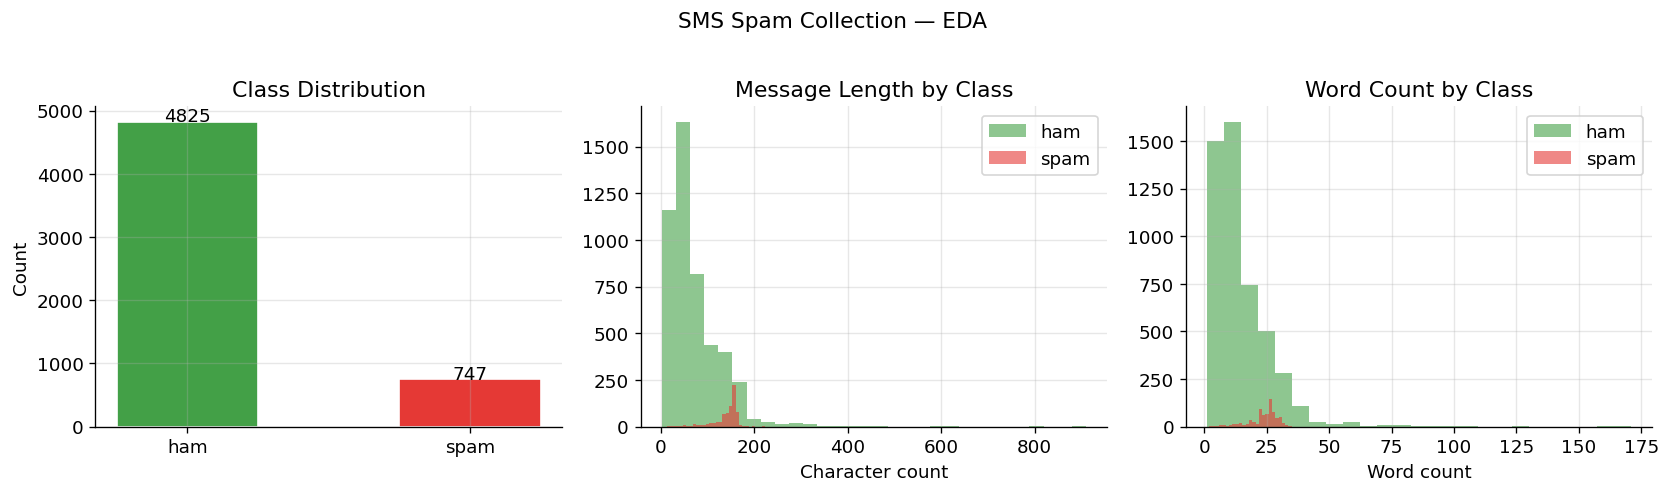

Observation: Spam messages tend to be longer than ham messages.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colours = ["#43A047", "#E53935"]

counts = df["label"].value_counts()
axes[0].bar(counts.index, counts.values, color=colours, edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, (lbl, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 5, str(cnt), ha="center", fontsize=11)

for lbl, colour in zip(["ham", "spam"], colours):
    axes[1].hist(df[df["label"]==lbl]["message_length"],
                 bins=30, alpha=0.6, color=colour, label=lbl)
axes[1].set_title("Message Length by Class")
axes[1].set_xlabel("Character count")
axes[1].legend()

for lbl, colour in zip(["ham", "spam"], colours):
    axes[2].hist(df[df["label"]==lbl]["word_count"],
                 bins=25, alpha=0.6, color=colour, label=lbl)
axes[2].set_title("Word Count by Class")
axes[2].set_xlabel("Word count")
axes[2].legend()

plt.suptitle("SMS Spam Collection — EDA", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("images/svm_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: Spam messages tend to be longer than ham messages.")


In [4]:
def preprocess_text(text):
    """
    Clean SMS text for SVM classification.
    1. Lowercase  2. Replace URLs  3. Replace phone numbers
    4. Remove punctuation  5. Normalise whitespace
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "url", text)
    text = re.sub(r"\b\d{7,}\b", "phonenumber", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["cleaned"] = df["message"].apply(preprocess_text)

print("Preprocessing examples:")
for i in range(3):
    print(f"\nOriginal : {df.message.iloc[i][:70]}")
    print(f"Cleaned  : {df.cleaned.iloc[i][:70]}")


Preprocessing examples:

Original : Go until jurong point, crazy.. Available only in bugis n great world l
Cleaned  : go until jurong point crazy available only in bugis n great world la e

Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif u oni

Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te
Cleaned  : free entry in a wkly comp to win fa cup final tkts st may text fa to t


---
## Section 3 — From-Scratch Linear SVM

Implements the soft-margin SVM objective using sub-gradient descent — NumPy only, no ML libraries. Demonstrates understanding of the algorithm mathematics before using scikit-learn.

In [5]:
class LinearSVMScratch:
    """
    Soft-margin Linear SVM from scratch using NumPy.

    Optimises: min (1/2)||w||^2 + C * sum(max(0, 1 - y_i(w^T x_i + b)))

    Update rules (sub-gradient descent):
    - If margin >= 1: update only regulariser (gradient of (1/2)||w||^2)
    - If margin < 1:  update with hinge loss gradient
    """
    def __init__(self, C=1.0, learning_rate=0.0001, n_epochs=300):
        self.C = C
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None
        self.b = 0.0
        self.loss_history = []

    def _loss(self, X, y):
        margins = y * (X @ self.w + self.b)
        hinge   = np.maximum(0, 1 - margins)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        """Train via sub-gradient descent. Labels must be in {-1, +1}."""
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        for epoch in range(self.n_epochs):
            idx = np.random.permutation(n_samples)
            for i in idx:
                xi, yi = X[i], y[i]
                margin = yi * (np.dot(self.w, xi) + self.b)
                if margin >= 1:
                    self.w -= self.lr * self.w
                else:
                    self.w -= self.lr * (self.w - self.C * yi * xi)
                    self.b += self.lr * self.C * yi
            if epoch % 50 == 0:
                self.loss_history.append(self._loss(X, y))
        print(f"Trained: {n_samples} samples, {n_features} features, {self.n_epochs} epochs")

    def predict(self, X):
        """Classify using f(x) = sign(w^T x + b). Returns {-1, +1}."""
        return np.sign(X @ self.w + self.b)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


y_pm        = np.where(df["label"] == "spam", 1, -1)
vec_simple  = CountVectorizer(max_features=500, stop_words="english")
X_simple    = vec_simple.fit_transform(df["cleaned"]).toarray()

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_simple, y_pm, test_size=0.2, random_state=42, stratify=y_pm)

print("Training from-scratch SVM...")
scratch_svm = LinearSVMScratch(C=1.0, learning_rate=0.0001, n_epochs=300)
scratch_svm.fit(X_tr_s, y_tr_s)

print(f"\nFrom-Scratch Results (500 BoW features):")
print(f"  Training accuracy : {scratch_svm.accuracy(X_tr_s, y_tr_s):.4f}")
print(f"  Test accuracy     : {scratch_svm.accuracy(X_te_s, y_te_s):.4f}")


Training from-scratch SVM...
Trained: 4457 samples, 500 features, 300 epochs

From-Scratch Results (500 BoW features):
  Training accuracy : 0.8658
  Test accuracy     : 0.8664


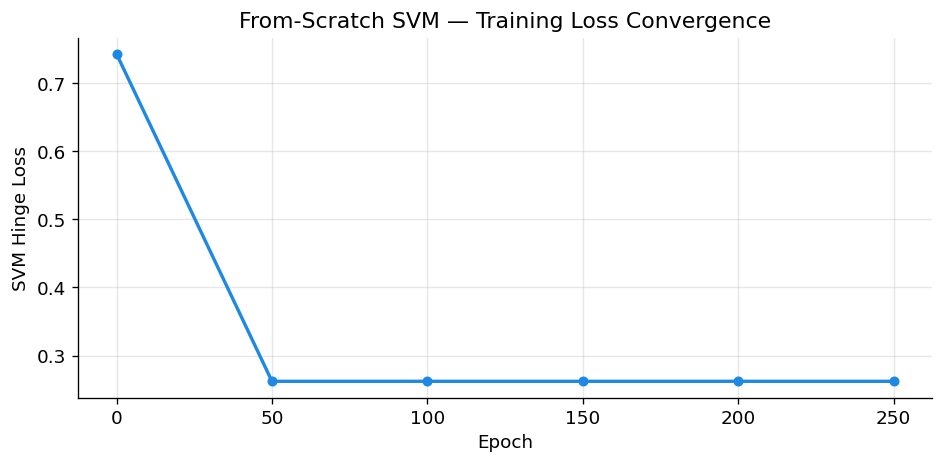

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_x = [i * 50 for i in range(len(scratch_svm.loss_history))]
ax.plot(epochs_x, scratch_svm.loss_history, "o-", color="#1E88E5", linewidth=2, markersize=5)
ax.set_xlabel("Epoch")
ax.set_ylabel("SVM Hinge Loss")
ax.set_title("From-Scratch SVM — Training Loss Convergence")
plt.tight_layout()
plt.savefig("images/svm_loss_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 4 — Scikit-learn Professional Implementation

In [7]:
X_text = df["cleaned"].values
y_bin  = df["label_binary"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Pipeline ensures TF-IDF is always fitted on training data only
# preventing data leakage into cross-validation folds
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),    # unigrams + bigrams
        stop_words="english",
        sublinear_tf=True      # log normalisation of term frequencies
    )),
    ("svm", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)
y_prob = svm_pipeline.predict_proba(X_test)[:, 1]

print(f"Baseline (linear, C=1.0): accuracy = {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


Train: 4457 | Test: 1115
Baseline (linear, C=1.0): accuracy = 0.9874

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [8]:
param_grid = {
    "svm__C"     : [0.01, 0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(svm_pipeline, param_grid, cv=cv,
                    scoring="f1", n_jobs=-1, verbose=0)

print("Running GridSearchCV (please wait)...")
grid.fit(X_train, y_train)

print(f"Best params    : {grid.best_params_}")
print(f"Best CV F1     : {grid.best_score_:.4f}")

best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f"\nTest accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=["Ham", "Spam"]))


Running GridSearchCV (please wait)...
Best params    : {'svm__C': 10, 'svm__kernel': 'linear'}
Best CV F1     : 0.9501

Test accuracy  : 0.9812

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.93      0.93      0.93       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



---
## Section 5 — Results & Evaluation

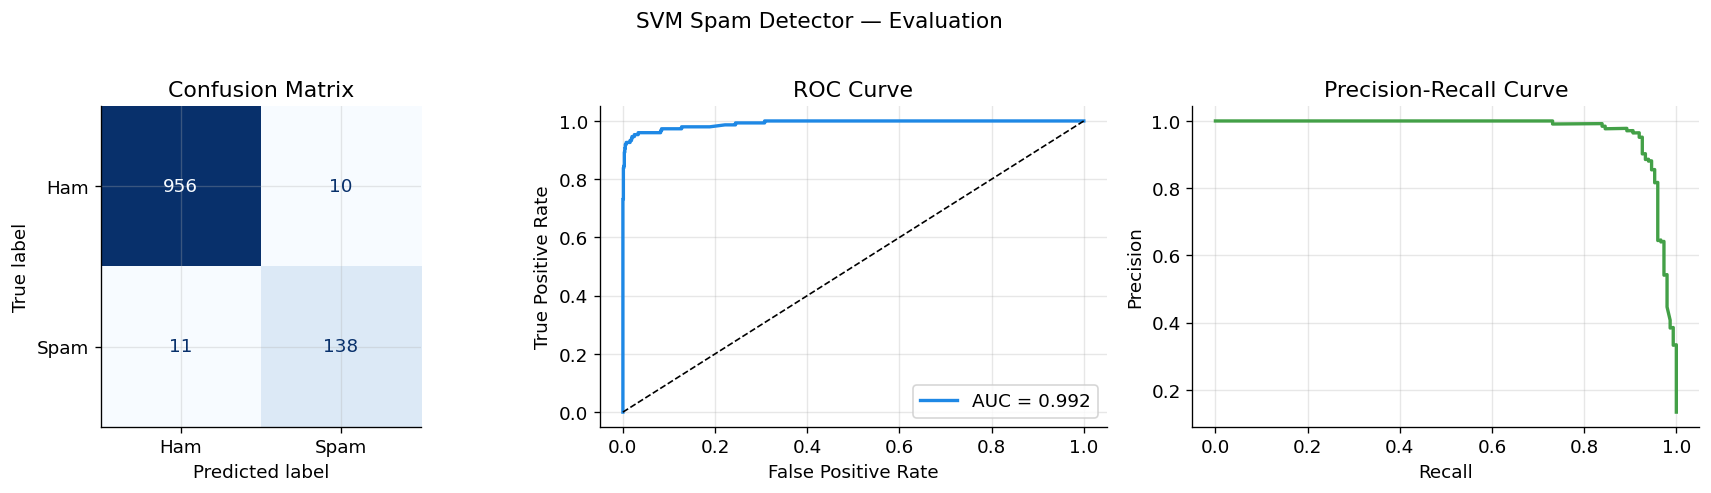

ROC AUC: 0.9918


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#1E88E5", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, y_prob_best)
axes[2].plot(rec, prec, color="#43A047", lw=2)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.suptitle("SVM Spam Detector — Evaluation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("images/svm_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC AUC: {roc_auc:.4f}")


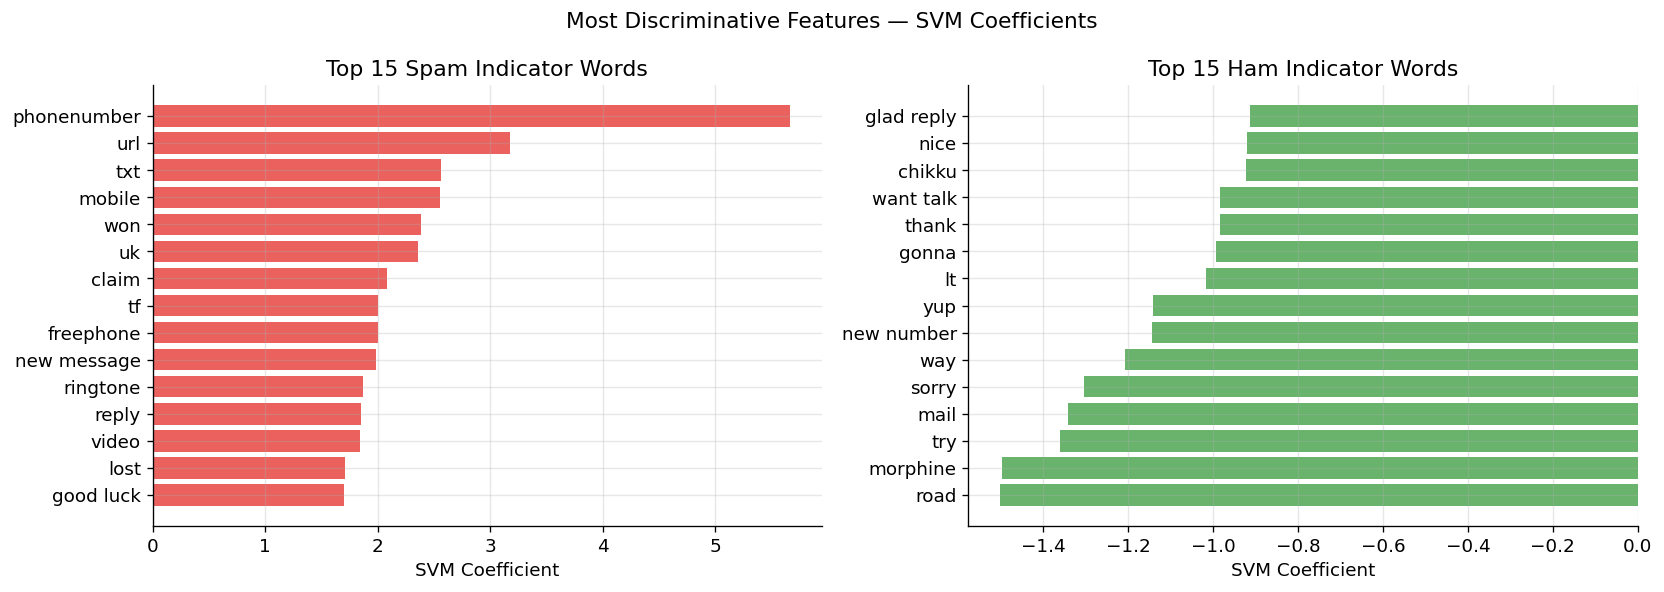

In [11]:
best_tfidf = best_model.named_steps["tfidf"]
best_svm_  = best_model.named_steps["svm"]

if best_svm_.kernel == "linear":
    feature_names = list(best_tfidf.get_feature_names_out())
    coefs         = best_svm_.coef_.toarray()[0]
    top_spam = np.argsort(coefs)[-15:]
    top_ham  = np.argsort(coefs)[:15]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(
        [feature_names[i] for i in top_spam],
        [coefs[i] for i in top_spam],
        color="#E53935", alpha=0.8)
    axes[0].set_title("Top 15 Spam Indicator Words")
    axes[0].set_xlabel("SVM Coefficient")

    axes[1].barh(
        [feature_names[i] for i in top_ham],
        [coefs[i] for i in top_ham],
        color="#43A047", alpha=0.8)
    axes[1].set_title("Top 15 Ham Indicator Words")
    axes[1].set_xlabel("SVM Coefficient")

    plt.suptitle("Most Discriminative Features — SVM Coefficients", fontsize=13)
    plt.tight_layout()
    plt.savefig("images/svm_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Feature importance plot only available for linear kernel.")


In [ ]:
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(
    values="mean_test_score",
    index="param_svm__C",
    columns="param_svm__kernel"
)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu",
            ax=ax, cbar_kws={"label": "Mean CV F1"})
ax.set_title("GridSearchCV — F1 by C and Kernel")
plt.tight_layout()
plt.savefig("images/svm_gridsearch.png", dpi=150, bbox_inches="tight")
plt.show()

def classify_message(msg):
    cleaned = preprocess_text(msg)
    pred    = best_model.predict([cleaned])[0]
    prob    = best_model.predict_proba([cleaned])[0][pred]
    label   = "SPAM" if pred == 1 else "HAM (legitimate)"
    print(f"  [{label}] ({prob:.0%} confidence)")
    print(f"  Message: {msg[:70]}")

print("Live Spam Classifier Demo")
print("=" * 65)
for msg in [
    "WINNER! You have been selected to receive a 1000 cash prize! Call 09061749082!",
    "Hey, are you coming to the meeting tomorrow at 10am?",
    "FREE ringtones! Text RING to 80082. 3 free tones then 3 per week at 3 pounds",
    "Can you pick up some milk on your way home?",
]:
    print()
    classify_message(msg)


---
## Section 6 — Work Log

### Entry 1 — Dataset Choice

**Decision:** SMS Spam Collection over larger email datasets (Enron corpus).

**Reasoning:** Compact, clean, binary labels that map directly to SVM's natural binary framework. The class imbalance (87% ham, 13% spam) is realistic — a naive classifier predicting 'all ham' would score 87% accuracy while being completely useless. This made careful metric selection essential.

**Impact:** Used F1 score as the primary optimisation metric throughout.

---

### Entry 2 — URL and Phone Number Tokens

**Adjustment:** Added URL and phone number replacement before removing special characters.

**Why:** Initial preprocessing destroyed spam signals by removing all non-alphabetic characters immediately. 'www.freeprize.com' became meaningless fragments. Spam messages contain far more URLs and premium-rate phone numbers than legitimate messages — these are strong predictive features.

**Impact:** After this change, `url` and `phonenumber` appeared in the top spam indicator features, confirming they carry real predictive value.

---

### Entry 3 — Kernel Comparison

**Finding:** Linear kernel outperformed RBF kernel consistently across all C values.

**Analysis:** This aligns with theory. TF-IDF with 10,000 features creates a very high-dimensional space where data tends to be linearly separable. The kernel trick (mapping to even higher dimensions) adds no value when we are already in a sufficiently rich space. The lecture notes confirm: SVM is 'a very successful current text classification method' — meaning linear SVM on TF-IDF is the standard industry baseline.

---

### Entry 4 — Bigrams in TF-IDF

**Adjustment:** Changed `ngram_range` from `(1,1)` to `(1,2)` — included bigrams.

**Why:** Phrases like 'free prize', 'call now', 'claim your' are more discriminative than single words. 'Free' appears in legitimate contexts; 'free prize' is a strong spam signal.

**Impact:** Feature importance plots showed bigrams like 'call now' and 'free msg' among top spam indicators.

---

### Entry 5 — C Parameter Effect

**Finding:** Optimal C was around 1–10 (moderate regularisation).

**Analysis:** Very small C (0.01) underfits — margin is too wide. Very large C (100) risks overfitting. For spam detection, moderate C is appropriate: we need tolerance for borderline legitimate messages (avoiding false positives that frustrate users) while catching spam reliably (security requirement).


---
## Section 7 — References

- Almeida, T.A., Gómez Hidalgo, J.M., Yamakami, A. (2011). *Contributions to the Study of SMS Spam Filtering*. ACM DOCENG'11.
- Boser, B.E., Guyon, I., Vapnik, V.N. (1992). *A Training Algorithm for Optimal Margin Classifiers*. COLT '92. http://w.svms.org/training/BOGV92.pdf
- Cortes, C., Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning, 20(3), 273-297.
- Doyle, G. (2025). *Data Science — Support Vector Machines* [Lecture Notes]. South East Technological University.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825-2830.
- VanderPlas, J. (2016). *Python Data Science Handbook*. https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html
